##Assignment 2 — Real-Time Data Processing with Pandas and NumPy

##AITU Smart Classroom Energy Stream
#Name:Aliya,Ayazhan
#Group:BDA2404

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "Time": [
        "10:00", "10:01", "10:02", "10:03",
        "10:04", "10:05", "10:06", "10:07",
        "10:08", "10:09", "10:10", "10:11"
    ],

    "Room": [
        "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101",
        "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101",
        "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101"
    ],

    "Temp_C": [
        21.5, 21.7, None, 22.1,
        22.3, 22.5, 22.6, 22.7,
        22.9, 23.1, 23.2, 23.3
    ],

    "CO2_ppm": [
        620, 650, 690, 720,
        None, 780, 810, 830,
        850, 900, 920, 950
    ],

    "Occupancy": [
        18, 20, 22, 24,
        25, 27, 29, None,
        31, 33, 35, 37
    ],

    "Power_kW": [
        3.2, 3.4, 3.5, 3.8,
        4.0, 4.2, 4.4, 4.6,
        4.8, 5.1, 5.4, 5.7
    ]
}

df = pd.DataFrame(data)

df

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620.0,18.0,3.2
1,10:01,C1.3.101,21.7,650.0,20.0,3.4
2,10:02,C1.3.101,NaN,690.0,22.0,3.5
3,10:03,C1.3.101,22.1,720.0,24.0,3.8
4,10:04,C1.3.101,22.3,NaN,25.0,4.0
5,10:05,C1.3.101,22.5,780.0,27.0,4.2
6,10:06,C1.3.101,22.6,810.0,29.0,4.4
7,10:07,C1.3.101,22.7,830.0,NaN,4.6
8,10:08,C1.3.101,22.9,850.0,31.0,4.8
9,10:09,C1.3.101,23.1,900.0,33.0,5.1


In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Time         0
Room         0
Temp_C       1
CO2_ppm      1
Occupancy    1
Power_kW     0
dtype: int64


#Part A — Cleaning

In [4]:
df["Temp_C"] = df["Temp_C"].interpolate()

df["CO2_ppm"] = df["CO2_ppm"].interpolate()

df["Occupancy"] = df["Occupancy"].ffill()

print(df)

     Time      Room  Temp_C  CO2_ppm  Occupancy  Power_kW
0   10:00  C1.3.101    21.5    620.0       18.0       3.2
1   10:01  C1.3.101    21.7    650.0       20.0       3.4
2   10:02  C1.3.101    21.9    690.0       22.0       3.5
3   10:03  C1.3.101    22.1    720.0       24.0       3.8
4   10:04  C1.3.101    22.3    750.0       25.0       4.0
5   10:05  C1.3.101    22.5    780.0       27.0       4.2
6   10:06  C1.3.101    22.6    810.0       29.0       4.4
7   10:07  C1.3.101    22.7    830.0       29.0       4.6
8   10:08  C1.3.101    22.9    850.0       31.0       4.8
9   10:09  C1.3.101    23.1    900.0       33.0       5.1
10  10:10  C1.3.101    23.2    920.0       35.0       5.4
11  10:11  C1.3.101    23.3    950.0       37.0       5.7


In [5]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Time         0
Room         0
Temp_C       0
CO2_ppm      0
Occupancy    0
Power_kW     0
dtype: int64


In [6]:
print("Cleaned values:")

print("Temperature at 10:02:",
      df.loc[df["Time"] == "10:02", "Temp_C"].iloc[0])

print("CO2 at 10:04:",
      df.loc[df["Time"] == "10:04", "CO2_ppm"].iloc[0])

print("Occupancy at 10:07:",
      df.loc[df["Time"] == "10:07", "Occupancy"].iloc[0])

Cleaned values:
Temperature at 10:02: 21.9
CO2 at 10:04: 750.0
Occupancy at 10:07: 29.0


#Part B — 3-minute rolling mean

In [7]:
df["Time_dt"] = pd.to_datetime(df["Time"], format="%H:%M")

In [8]:
rolling = (
    df.set_index("Time_dt")[["Temp_C", "CO2_ppm", "Power_kW"]]
    .rolling("3min")
    .mean()
)

rolling

,Temp_C,CO2_ppm,Power_kW
Time_dt,,,
1900-01-01 10:00:00,21.500000,620.000000,3.200000
1900-01-01 10:01:00,21.600000,635.000000,3.300000
1900-01-01 10:02:00,21.700000,653.333333,3.366667
1900-01-01 10:03:00,21.900000,686.666667,3.566667
1900-01-01 10:04:00,22.100000,720.000000,3.766667
1900-01-01 10:05:00,22.300000,750.000000,4.000000
1900-01-01 10:06:00,22.466667,780.000000,4.200000
1900-01-01 10:07:00,22.600000,806.666667,4.400000
1900-01-01 10:08:00,22.733333,830.000000,4.600000


In [9]:
rolling_result = rolling.iloc[2:7].copy()

rolling_result

,Temp_C,CO2_ppm,Power_kW
Time_dt,,,
1900-01-01 10:02:00,21.700000,653.333333,3.366667
1900-01-01 10:03:00,21.900000,686.666667,3.566667
1900-01-01 10:04:00,22.100000,720.000000,3.766667
1900-01-01 10:05:00,22.300000,750.000000,4.000000
1900-01-01 10:06:00,22.466667,780.000000,4.200000


In [10]:
rolling_result = rolling_result.round(3)

rolling_result.columns = [
    "Temp rolling mean",
    "CO2 rolling mean",
    "Power rolling mean"
]

rolling_result

,Temp rolling mean,CO2 rolling mean,Power rolling mean
Time_dt,,,
1900-01-01 10:02:00,21.700,653.333,3.367
1900-01-01 10:03:00,21.900,686.667,3.567
1900-01-01 10:04:00,22.100,720.000,3.767
1900-01-01 10:05:00,22.300,750.000,4.000
1900-01-01 10:06:00,22.467,780.000,4.200


##Part C — Feature Engineering

In [11]:
df["occupancy_density"] = df["Occupancy"] / 40

df["energy_per_student"] = (
    df["Power_kW"] / df["Occupancy"]
)

df["comfort_flag"] = (
    (df["CO2_ppm"] <= 1000) &
    (df["Temp_C"].between(20, 24))
)

In [12]:
feature_result = df[
    df["Time"].isin(["10:03", "10:06", "10:09", "10:11"])
][[
    "Time",
    "occupancy_density",
    "energy_per_student",
    "comfort_flag"
]]

feature_result.round(3)

,Time,occupancy_density,energy_per_student,comfort_flag
3,10:03,0.600,0.158,True
6,10:06,0.725,0.152,True
9,10:09,0.825,0.155,True
11,10:11,0.925,0.154,True


##Part D — Statistics

In [13]:
print("Temperature statistics")
print("Mean:", round(df["Temp_C"].mean(), 3))
print("Median:", round(df["Temp_C"].median(), 3))
print("Minimum:", round(df["Temp_C"].min(), 3))
print("Maximum:", round(df["Temp_C"].max(), 3))

print("\nCO2 statistics")
print("Mean:", round(df["CO2_ppm"].mean(), 3))
print("Maximum:", round(df["CO2_ppm"].max(), 3))

Temperature statistics
Mean: 22.483
Median: 22.55
Minimum: 21.5
Maximum: 23.3

CO2 statistics
Mean: 789.167
Maximum: 950.0


In [14]:
max_power = df.loc[df["Power_kW"].idxmax()]

print("Highest power consumption:")
print("Time:", max_power["Time"])
print("Power:", max_power["Power_kW"], "kW")

Highest power consumption:
Time: 10:11
Power: 5.7 kW


#Correlation

In [16]:
correlation = df["Occupancy"].corr(df["Power_kW"])

print("Occupancy-Power correlation:",
      round(correlation, 3))

Occupancy-Power correlation: 0.995


#Part E

#Graph 1 Rolling CO₂ and Temperature

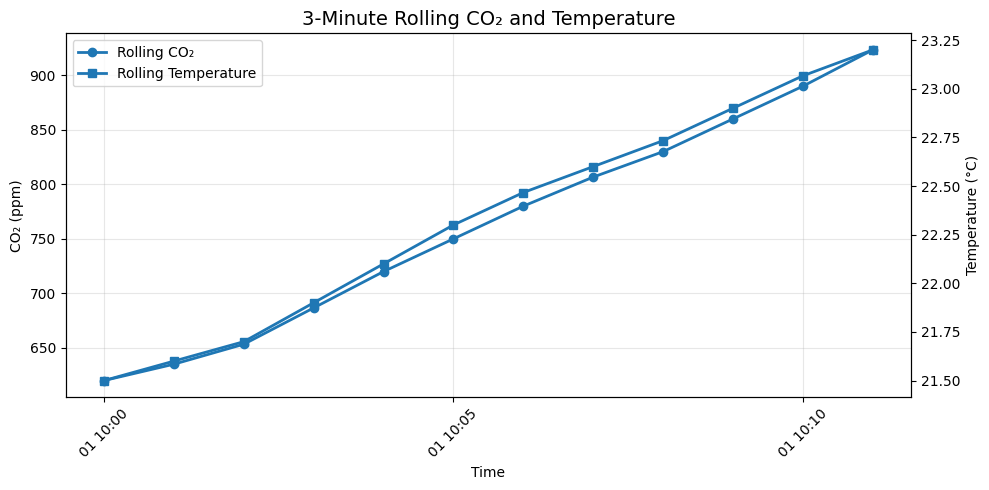

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Rolling CO2
ax1.plot(
    rolling.index,
    rolling["CO2_ppm"],
    marker="o",
    linewidth=2,
    label="Rolling CO₂"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("CO₂ (ppm)")
ax1.tick_params(axis="x", rotation=45)

# Rolling Temperature
ax2 = ax1.twinx()

ax2.plot(
    rolling.index,
    rolling["Temp_C"],
    marker="s",
    linewidth=2,
    label="Rolling Temperature"
)

ax2.set_ylabel("Temperature (°C)")

plt.title("3-Minute Rolling CO₂ and Temperature", fontsize=14)

ax1.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

#Graph 2 Classroom Occupancy vs Power

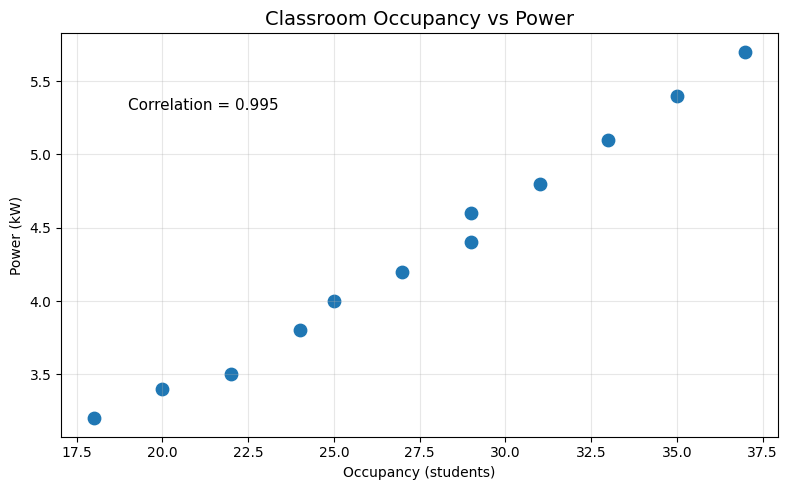

In [22]:
correlation = df["Occupancy"].corr(df["Power_kW"])

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Occupancy"],
    df["Power_kW"],
    s=80
)

plt.title("Classroom Occupancy vs Power", fontsize=14)
plt.xlabel("Occupancy (students)")
plt.ylabel("Power (kW)")
plt.grid(True, alpha=0.3)

plt.text(
    19,
    5.3,
    f"Correlation = {correlation:.3f}",
    fontsize=11
)

plt.tight_layout()
plt.show()

Operational insights: CO₂ increases as classroom occupancy increases, so ventilation can be monitored during periods of high occupancy. Power consumption also increases with occupancy, which can help facility management understand periods of higher energy demand.

In [19]:
# Validation test

assert df["Temp_C"].isnull().sum() == 0
assert df["CO2_ppm"].isnull().sum() == 0
assert df["Occupancy"].isnull().sum() == 0

assert df["Temp_C"].between(20, 24).all()
assert (df["CO2_ppm"] <= 1000).all()

print("Validation test passed successfully.")

Validation test passed successfully.


#Cleaned dataset

In [20]:
cleaned_dataset = df.drop(columns=["Time_dt"])

cleaned_dataset.to_csv(
    "cleaned_classroom_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
